In [228]:
try:
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    from scipy import stats, signal
    from scipy.fft import fft, fftfreq
    from statsmodels.tsa.stattools import adfuller, kpss
    from statsmodels.tsa.seasonal import seasonal_decompose
    from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
    from sklearn.tree import DecisionTreeRegressor
    from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
    from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
    import optuna
    import warnings
    import openpyxl
except ImportError:
    %pip install numpy pandas matplotlib seaborn scipy statsmodels scikit-learn optuna openpyxl
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    from scipy import stats, signal
    from scipy.fft import fft, fftfreq
    from statsmodels.tsa.stattools import adfuller, kpss
    from statsmodels.tsa.seasonal import seasonal_decompose
    from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
    from sklearn.tree import DecisionTreeRegressor
    from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
    from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
    import optuna
    import warnings

warnings.filterwarnings('ignore')

## Считываем данные из файла Excel
### ЗАмечаем, что названия листов в файле закодированы

In [229]:
FILE_PATH = "have_fun.xlsx"

wb = openpyxl.load_workbook(FILE_PATH, data_only=True)
all_sheets = wb.sheetnames
print(all_sheets)

['Ëèñò1', 'Лист1', 'ÌÀÈ', 'ýòî', 'ÿ', '!', 'Ëèñò2_ñòðîêîâûå_NaN_âûáðîñû', 'Ëèñò3_ñìåøàííûå_òèïû']


In [230]:
dfs = {}
for sheet in all_sheets:
    df = pd.read_excel(FILE_PATH, sheet_name=sheet, engine='openpyxl')
    dfs[sheet] = df
    print(
        f" Лист: {sheet} | Shape: {df.shape} | Columns: {list(df.columns)}")
    print(df.head(3))

 Лист: Ëèñò1 | Shape: (125124, 10) | Columns: ['temperature_2m', 'relative_humidity_2m', 'precipitation', 'rain', 'snowfall', 'weathercode', 'wind_speed_10m', 'surface_pressure', 'ds', 'city']
   temperature_2m  relative_humidity_2m  precipitation  rain  snowfall  \
0             3.8                    82            0.0   0.0       0.0   
1            -3.0                    70            0.0   0.0       0.0   
2            -1.3                    86            0.0   0.0       0.0   

   weathercode  wind_speed_10m  surface_pressure                  ds  \
0            3            19.1       1010.000000 2020-01-31 02:00:00   
1            3            24.0        981.900024 2025-02-28 09:00:00   
2            2             8.8       1021.200012 2022-01-03 02:00:00   

           city  
0     Ãåëåíäæèê  
1  Áëàãîâåùåíñê  
2     Ãåëåíäæèê  
 Лист: Лист1 | Shape: (0, 0) | Columns: []
Empty DataFrame
Columns: []
Index: []
 Лист: ÌÀÈ | Shape: (0, 0) | Columns: []
Empty DataFrame
Columns: []

In [231]:
SHEETS = ['Ëèñò1', 'Ëèñò2_ñòðîêîâûå_NaN_âûáðîñû', 'Ëèñò3_ñìåøàííûå_òèïû']
for sheet in all_sheets:
    if sheet in SHEETS:
        df= pd.read_excel(FILE_PATH, sheet_name=sheet)
        print(f"Лист {sheet}:")
        dfs[sheet] = df
        print(df.dtypes)
        print(dfs[sheet].head(3))

Лист Ëèñò1:
temperature_2m                 float64
relative_humidity_2m             int64
precipitation                  float64
rain                           float64
snowfall                       float64
weathercode                      int64
wind_speed_10m                 float64
surface_pressure               float64
ds                      datetime64[us]
city                               str
dtype: object
   temperature_2m  relative_humidity_2m  precipitation  rain  snowfall  \
0             3.8                    82            0.0   0.0       0.0   
1            -3.0                    70            0.0   0.0       0.0   
2            -1.3                    86            0.0   0.0       0.0   

   weathercode  wind_speed_10m  surface_pressure                  ds  \
0            3            19.1       1010.000000 2020-01-31 02:00:00   
1            3            24.0        981.900024 2025-02-28 09:00:00   
2            2             8.8       1021.200012 2022-01-03 02:00:00   

### Так как названия листов, а так же названия городов являются нечитаемыми, мы исправляем кодировку. Так же можно заметить, что в таблице есть пустые колонки, которые мы удаляем. После этого мы приводим числовые поеказатели в числа, используя для этого функцию `pd.to_numeric`. Данная функция переводит значения в float, а нечитаемые показатели меняет на NaN.

In [232]:
def fix_cp1251(x):
    return x.encode('latin1').decode('cp1251') if isinstance(x, str) else x


raw_sheets = ['Ëèñò1', 'Ëèñò2_ñòðîêîâûå_NaN_âûáðîñû', 'Ëèñò3_ñìåøàííûå_òèïû']
clean_sheets = [fix_cp1251(s) for s in raw_sheets]

dfs = {}
for raw, clean in zip(raw_sheets, clean_sheets):
    df = pd.read_excel(FILE_PATH, sheet_name=raw)

    df = df.loc[:, ~df.columns.str.startswith('Unnamed')]

    df['city'] = df['city'].apply(fix_cp1251)


    cols_to_num = ['temperature_2m', 'relative_humidity_2m', 'precipitation',
                   'rain', 'snowfall', 'weathercode', 'wind_speed_10m', 'surface_pressure']
    for c in cols_to_num:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='coerce')

    df['ds'] = pd.to_datetime(df['ds'])
    dfs[clean] = df

df_all = pd.concat(dfs.values(), ignore_index=True)
df_all = df_all.sort_values(['city', 'ds']).reset_index(drop=True)

print(f"Shape: {df_all.shape}")
print(f"Города: {df_all['city'].unique()}")
print(f"Типы данных:\n{df_all.dtypes}")
print(f"\nКоличество пропусков:\n{df_all.isna().sum()}")
print(df_all.head())

Shape: (373029, 10)
Города: <StringArray>
[   'БЛАГОВЕЩЕНСК',     'Благовещенс',    'Благовещенск',   'Благовещенскк',
       'ГЕЛЕНДЖИК',        'Геленджи',       'Геленджик',      'Геленджикк',
           'Мосва',          'Москва',         'Находка', 'Санкт-Петербург',
             'Соч',            'Сочи',             'Счи',            'Сычи',
    'благовещенск',       'геленджик',               nan]
Length: 19, dtype: str
Типы данных:
temperature_2m                 float64
relative_humidity_2m           float64
precipitation                  float64
rain                           float64
snowfall                       float64
weathercode                    float64
wind_speed_10m                 float64
surface_pressure               float64
ds                      datetime64[us]
city                               str
dtype: object

Количество пропусков:
temperature_2m          6778
relative_humidity_2m    2459
precipitation           6157
rain                    2484
snowfall     

## Удаляем строки, где нет даты или города, тк их нельзя восстановить

In [233]:
df_all = df_all.dropna(subset=['ds', 'city']).copy()
print(f"После удаления строк без ds/city: {df_all.shape}")

После удаления строк без ds/city: (370541, 10)


### Обрабатываем названия городов: убираем опечатки. По итогу в датафрейме представлены данные по 6 городам: Благовещенск, Геленджик, Москва, Сочи, Находка.

In [234]:
df_all['city_clean'] = df_all['city'].astype(str).str.strip().str.title()

CITY_FIXES = {
    'Благовещенс': 'Благовещенск',
    'Благовещенскк': 'Благовещенск',
    'Геленджи': 'Геленджик',
    'Геленджикк': 'Геленджик',
    'Мосва': 'Москва',
    'Соч': 'Сочи',
    'Счи': 'Сочи',
    'Сычи': 'Сочи',
}
df_all['city_clean'] = df_all['city_clean'].replace(CITY_FIXES)

df_all['city_clean'].unique()

<StringArray>
['Благовещенск', 'Геленджик', 'Москва', 'Находка', 'Санкт-Петербург', 'Сочи']
Length: 6, dtype: str

In [235]:
df_all = df_all.drop(columns=['city']).rename(columns={'city_clean': 'city'})
df_all.info()

<class 'pandas.DataFrame'>
Index: 370541 entries, 0 to 370541
Data columns (total 10 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   temperature_2m        366217 non-null  float64       
 1   relative_humidity_2m  370536 non-null  float64       
 2   precipitation         366839 non-null  float64       
 3   rain                  370541 non-null  float64       
 4   snowfall              370541 non-null  float64       
 5   weathercode           368700 non-null  float64       
 6   wind_speed_10m        367452 non-null  float64       
 7   surface_pressure      370541 non-null  float64       
 8   ds                    370541 non-null  datetime64[us]
 9   city                  370541 non-null  str           
dtypes: datetime64[us](1), float64(8), str(1)
memory usage: 31.1 MB


### Сортируем наши данные

In [236]:
df_all = df_all.sort_values(['city', 'ds']).reset_index(drop=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 122736 entries, 0 to 122735
Data columns (total 10 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   temperature_2m        121504 non-null  float64       
 1   relative_humidity_2m  122731 non-null  float64       
 2   precipitation         121504 non-null  float64       
 3   rain                  122736 non-null  float64       
 4   snowfall              122736 non-null  float64       
 5   weathercode           120895 non-null  float64       
 6   wind_speed_10m        121509 non-null  float64       
 7   surface_pressure      122736 non-null  float64       
 8   ds                    122736 non-null  datetime64[us]
 9   city                  122736 non-null  str           
dtypes: datetime64[us](1), float64(8), str(1)
memory usage: 9.4 MB


### Колонки rain, snowfail & precipitation имеют исключительно нулевые значения -> они не несут для нас никакой полезной инофрмации, мы их удаляем

In [237]:
df_all.describe()

,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure,ds
count,366217.000000,370536.000000,366839.000000,370541.000000,370541.000000,368700.000000,367452.000000,370541.000000,370541
mean,8.726913,73.999684,1.356006,0.093164,0.008090,11.110442,12.105874,1006.867734,2022-07-02 09:02:40.811354
min,-49.990098,9.000000,0.000000,0.000000,0.000000,0.000000,0.000000,800.185777,2019-01-01 00:00:00
25%,1.000000,63.000000,0.000000,0.000000,0.000000,0.000000,6.700000,998.000000,2020-10-01 00:00:00
50%,10.000000,78.000000,0.000000,0.000000,0.000000,3.000000,10.500000,1009.099976,2022-07-02 13:00:00
75%,17.900000,89.000000,0.000000,0.000000,0.000000,3.000000,15.600000,1016.099976,2024-04-01 14:00:00
max,79.974214,100.000000,998.260221,27.100000,4.620000,75.000000,249.928074,1199.037397,2025-12-31 23:00:00
std,12.278622,18.079113,31.136280,0.473154,0.064202,21.329754,10.335745,13.576025,NaN


In [238]:
df_all = df_all.drop(columns=['precipitation', 'rain', 'snowfall'])

### Убираем пропуски в нашем датасете, для этого исползуем линейную интерполяцию


In [239]:
numeric_cols = ['temperature_2m', 'relative_humidity_2m', 'weathercode', 
                'wind_speed_10m', 'surface_pressure']


def interpolate_city_group(group):
    city_name = group.name 

    group = group.set_index('ds')
    for col in numeric_cols:
        if col in group.columns:
            group[col] = group[col].interpolate(
                method='time', limit_direction='both')

    df_res = group.reset_index()
    df_res['city'] = city_name 
    return df_res


df_all = df_all.groupby('city', group_keys=False).apply(interpolate_city_group)
df_all = df_all.reset_index(drop=True)

In [240]:
df_all.info()

<class 'pandas.DataFrame'>
RangeIndex: 370541 entries, 0 to 370540
Data columns (total 7 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   ds                    370541 non-null  datetime64[us]
 1   temperature_2m        370541 non-null  float64       
 2   relative_humidity_2m  370541 non-null  float64       
 3   weathercode           370541 non-null  float64       
 4   wind_speed_10m        370541 non-null  float64       
 5   surface_pressure      370541 non-null  float64       
 6   city                  370541 non-null  str           
dtypes: datetime64[us](1), float64(5), str(1)
memory usage: 19.8 MB


In [241]:
print("Статистика температуры до обработки:")
for city in sorted(df_all['city'].unique()):
    temps = df_all[df_all['city'] == city]['temperature_2m']
    print(f"{city:20} | мин={temps.min():6.1f}C | макс={temps.max():6.1f}C")


Статистика температуры до обработки:
Благовещенск         | мин= -41.9C | макс=  35.0C
Геленджик            | мин= -10.0C | макс=  37.8C
Москва               | мин= -50.0C | макс=  80.0C
Находка              | мин= -50.0C | макс=  80.0C
Санкт-Петербург      | мин= -28.8C | макс=  35.7C
Сочи                 | мин= -11.2C | макс=  35.3C


### Ищем выбросы и заменяем их на Nan

In [242]:
IQR_K = 3.0

if 'month' not in df_all.columns:
    df_all['month'] = df_all['ds'].dt.month

total_nan_replaced = 0
outliers_per_col = {}

for city in df_all['city'].unique():
    city_mask = df_all['city'] == city

    for col in numeric_cols:
        if col not in outliers_per_col:
            outliers_per_col[col] = 0

        for month in range(1, 13):
            mask = city_mask & (df_all['month'] == month)
            values = df_all.loc[mask, col]

            if len(values) < 10:
                continue

            Q1 = values.quantile(0.25)
            Q3 = values.quantile(0.75)
            IQR = Q3 - Q1

            if IQR == 0:
                continue

            lower = Q1 - IQR_K * IQR
            upper = Q3 + IQR_K * IQR

            is_outlier = (values < lower) | (values > upper)
            n_outliers = is_outlier.sum()

            if n_outliers > 0:
                df_all.loc[mask & is_outlier, col] = np.nan
                total_nan_replaced += n_outliers
                outliers_per_col[col] += n_outliers

print(f"Всего значений заменено на NaN: {total_nan_replaced}")
print("По колонкам:")
for col, n in outliers_per_col.items():
    if n > 0:
        print(f"  {col}: {n} выбросов -> NaN")

Всего значений заменено на NaN: 49552
По колонкам:
  temperature_2m: 1243 выбросов -> NaN
  relative_humidity_2m: 106 выбросов -> NaN
  weathercode: 46775 выбросов -> NaN
  wind_speed_10m: 886 выбросов -> NaN
  surface_pressure: 542 выбросов -> NaN


### Обработка всех пропусков с помощью интерполяции

In [243]:
df_all = df_all.set_index('ds').sort_index()

for city in df_all['city'].unique():
    city_mask = df_all['city'] == city

    for col in numeric_cols:

        df_all.loc[city_mask, col] = df_all.loc[city_mask, col].interpolate(
            method='time',
            limit_direction='both' 
        )

df_all = df_all.reset_index()
print("Интерполяция завершена для всех колонок.")

df_all = df_all.drop('month', axis=1)

Интерполяция завершена для всех колонок.


In [244]:
print("\nСтатистика температуры после обработки:")
for city in sorted(df_all['city'].unique()):
    temps = df_all[df_all['city'] == city]['temperature_2m']
    print(f"{city:20} | мин={temps.min():6.1f}C | макс={temps.max():6.1f}C")


Статистика температуры после обработки:
Благовещенск         | мин= -41.9C | макс=  35.0C
Геленджик            | мин= -10.0C | макс=  37.8C
Москва               | мин= -33.8C | макс=  34.8C
Находка              | мин= -35.1C | макс=  33.2C
Санкт-Петербург      | мин= -28.8C | макс=  35.7C
Сочи                 | мин= -11.2C | макс=  35.3C


### Визуализация для Москвы. Все выбросы устранены

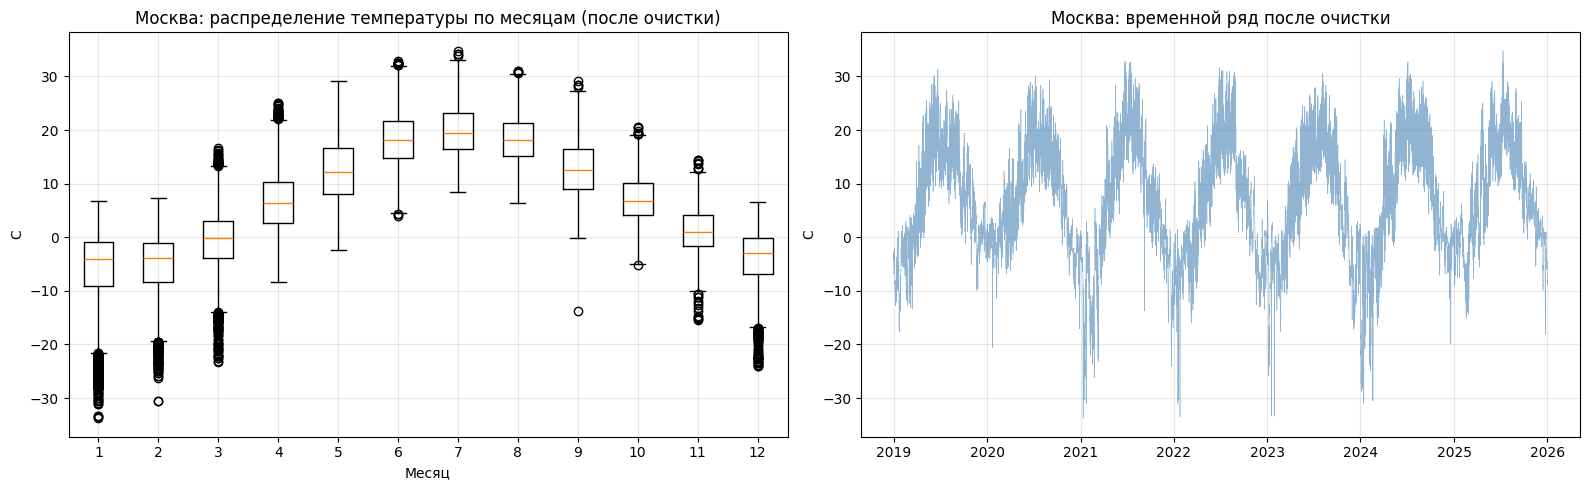

In [245]:
city_check = 'Москва'
city_df = df_all[df_all['city'] == city_check].copy()
city_df['month'] = city_df['ds'].dt.month

fig, axes = plt.subplots(1, 2, figsize=(16, 5))


monthly_data = [city_df[city_df['month'] == m]
                ['temperature_2m'].dropna() for m in range(1, 13)]
axes[0].boxplot(monthly_data)
axes[0].set_title(
    f'{city_check}: распределение температуры по месяцам (после очистки)')
axes[0].set_xlabel('Месяц')
axes[0].set_ylabel('C')
axes[0].grid(True, alpha=0.3)

city_df = city_df.set_index('ds').sort_index()
axes[1].plot(city_df.index, city_df['temperature_2m'],
             alpha=0.6, linewidth=0.4, color='steelblue')
axes[1].set_title(f'{city_check}: временной ряд после очистки')
axes[1].set_ylabel('C')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Итоговая сводка по всем городам по каждому показателю. После очистки данных все погодные параметры находятся в физически и климатически обоснованных пределах. Сезонные и географические особенности (например, низкие температуры в Благовещенске и высокие в Сочи) сохранены. Пиковые значения (максимум ветра 56.1 м/с в Геленджике, минимум давления 945.2 гПа в Москве) не противоречат возможным, хоть и редким, природным явлениям.

In [246]:
for col in numeric_cols:
    print(f"{col}:")
    print(f"{'Город':<20} {'Мин':>10} {'Макс':>10} {'Q1':>10} {'Q3':>10} {'Медиана':>10}")

    for city in sorted(df_all['city'].unique()):
        vals = df_all[df_all['city'] == city][col]
        print(f"{city:<20} {vals.min():>10.1f} {vals.max():>10.1f} "
              f"{vals.quantile(0.25):>10.1f} {vals.quantile(0.75):>10.1f} "
              f"{vals.median():>10.1f}")

temperature_2m:
Город                       Мин       Макс         Q1         Q3    Медиана
Благовещенск              -41.9       35.0      -11.7       16.2        3.4
Геленджик                 -10.0       37.8        8.1       21.2       13.8
Москва                    -33.8       34.8       -0.9       15.3        6.5
Находка                   -35.1       33.2       -2.3       17.0        7.9
Санкт-Петербург           -28.8       35.7        0.1       14.6        5.9
Сочи                      -11.2       35.3        9.2       21.4       14.7
relative_humidity_2m:
Город                       Мин       Макс         Q1         Q3    Медиана
Благовещенск               11.0      100.0       53.0       81.0       69.0
Геленджик                  16.0      100.0       64.0       88.0       78.0
Москва                     16.0      100.0       65.0       89.0       80.0
Находка                     9.0      100.0       53.0       90.0       74.0
Санкт-Петербург            15.0      100.0       7

### Boxplot'ы для всех колонок. Все выбросы логичны и не должны быть устранены

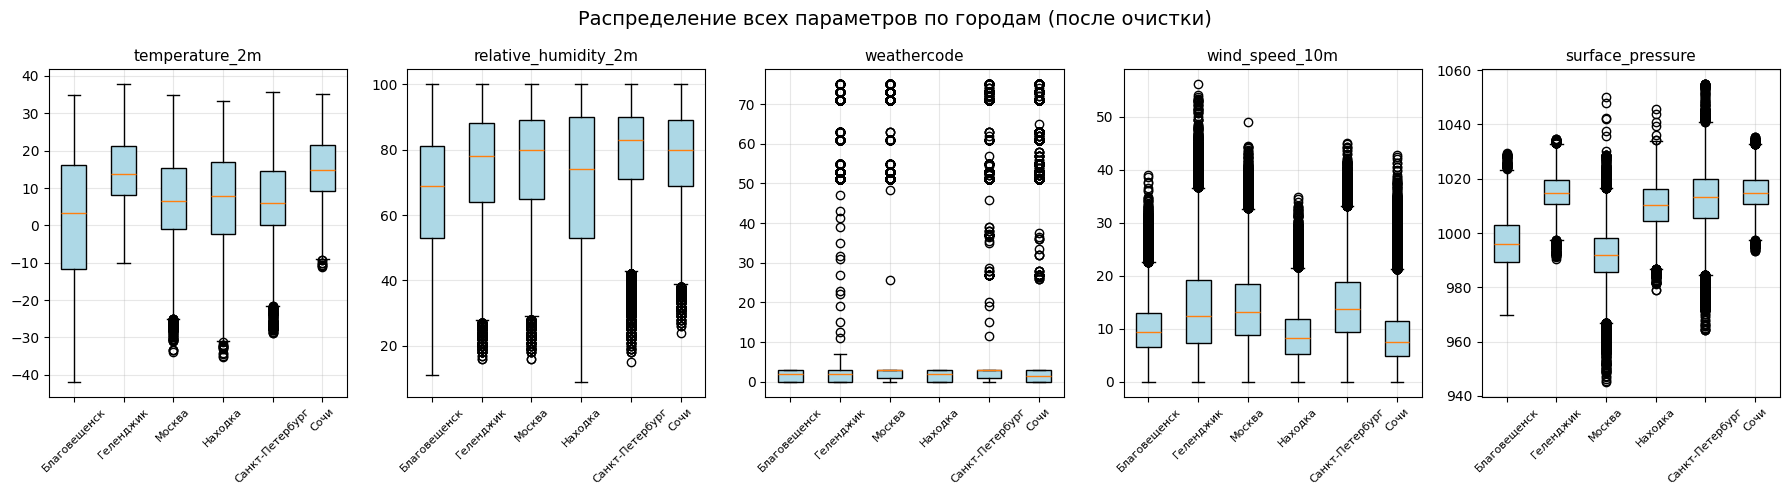

In [247]:
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(18, 5))
if len(numeric_cols) == 1:
    axes = [axes]

city_order = sorted(df_all['city'].unique())

for idx, col in enumerate(numeric_cols):
    ax = axes[idx]
    data = [df_all[df_all['city'] == city][col].dropna()
            for city in city_order]
    bp = ax.boxplot(data, tick_labels=city_order, patch_artist=True)

    for patch in bp['boxes']:
        patch.set_facecolor('lightblue')

    ax.set_title(col, fontsize=11)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle(
    'Распределение всех параметров по городам (после очистки)', fontsize=14)
plt.tight_layout()
plt.show()

### Анализ ременного ряда

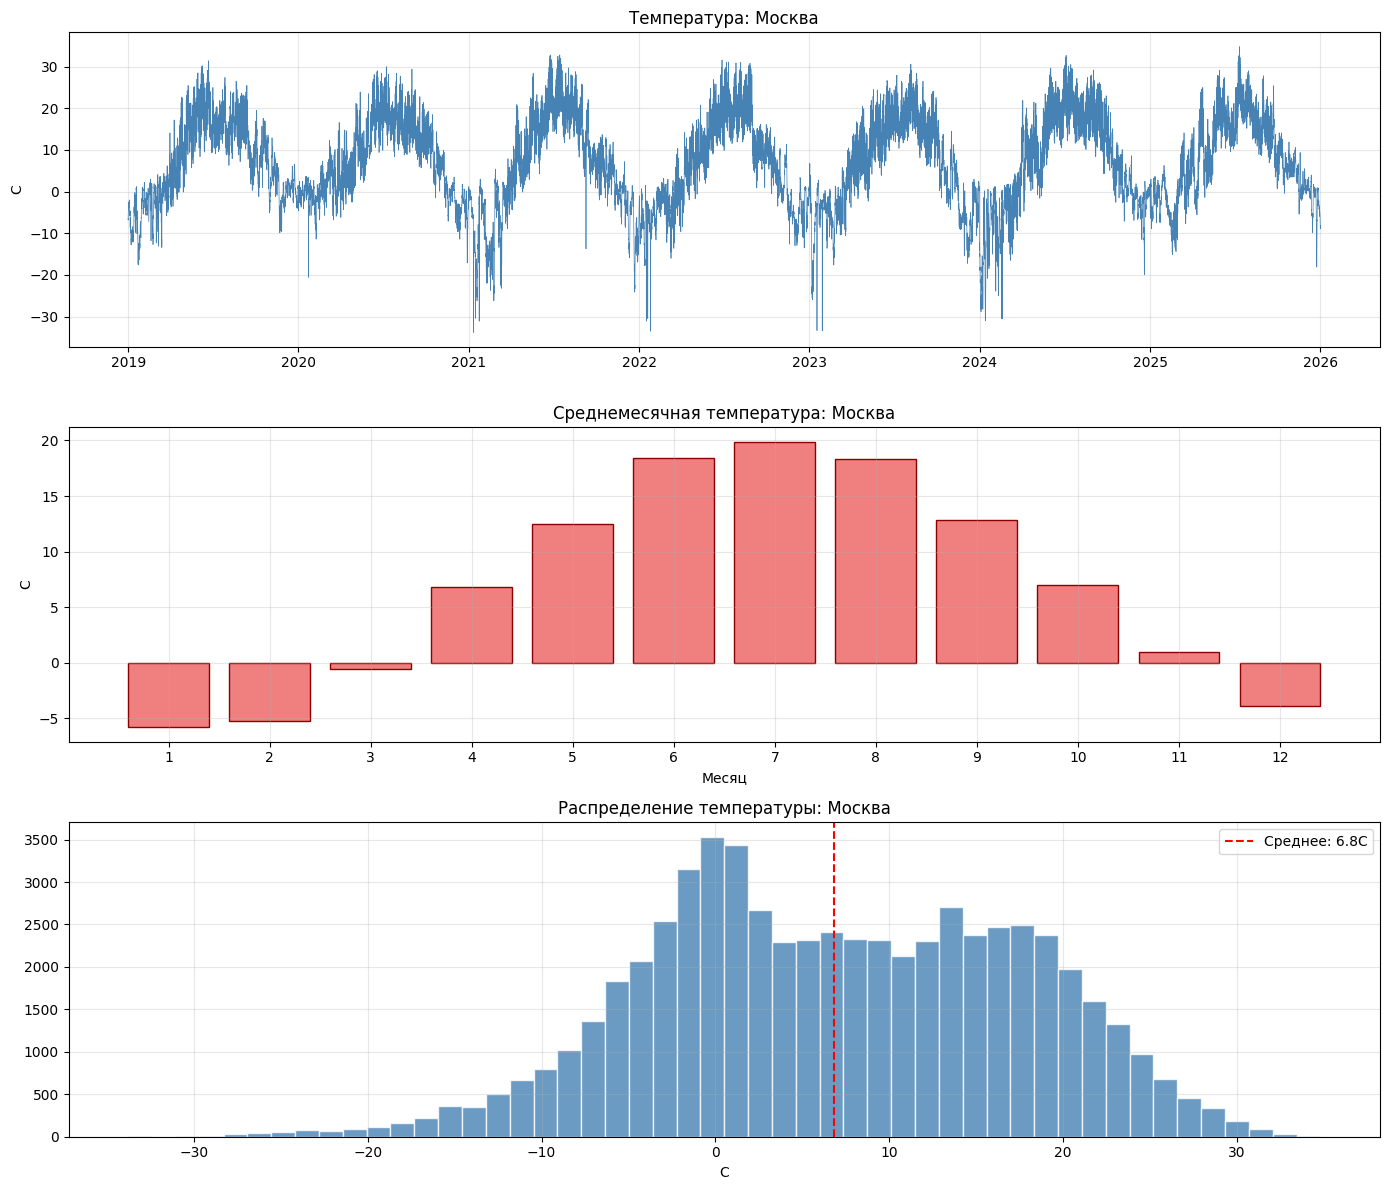

In [248]:
city = 'Москва'
city_data = df_all[df_all['city'] == city].set_index('ds').sort_index()
ts = city_data['temperature_2m']

fig, axes = plt.subplots(3, 1, figsize=(14, 12))


axes[0].plot(ts.index, ts.values, linewidth=0.5, color='steelblue')
axes[0].set_title(f'Температура: {city}')
axes[0].set_ylabel('C')
axes[0].grid(True, alpha=0.3)


monthly_avg = city_data.groupby(city_data.index.month)['temperature_2m'].mean()
axes[1].bar(monthly_avg.index, monthly_avg.values,
            color='lightcoral', edgecolor='darkred')
axes[1].set_title(f'Среднемесячная температура: {city}')
axes[1].set_xlabel('Месяц')
axes[1].set_ylabel('C')
axes[1].set_xticks(range(1, 13))
axes[1].grid(True, alpha=0.3)


axes[2].hist(ts.values, bins=50, color='steelblue',
             edgecolor='white', alpha=0.8)
axes[2].axvline(ts.mean(), color='red', linestyle='--',
                label=f'Среднее: {ts.mean():.1f}C')
axes[2].set_title(f'Распределение температуры: {city}')
axes[2].set_xlabel('C')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Проверям временной ряд на стационарность -> ряд стационарен. А так же декомпозируем ряд и используем спектральный анализ.

ADF p-value: 0.0000 | Стационарен


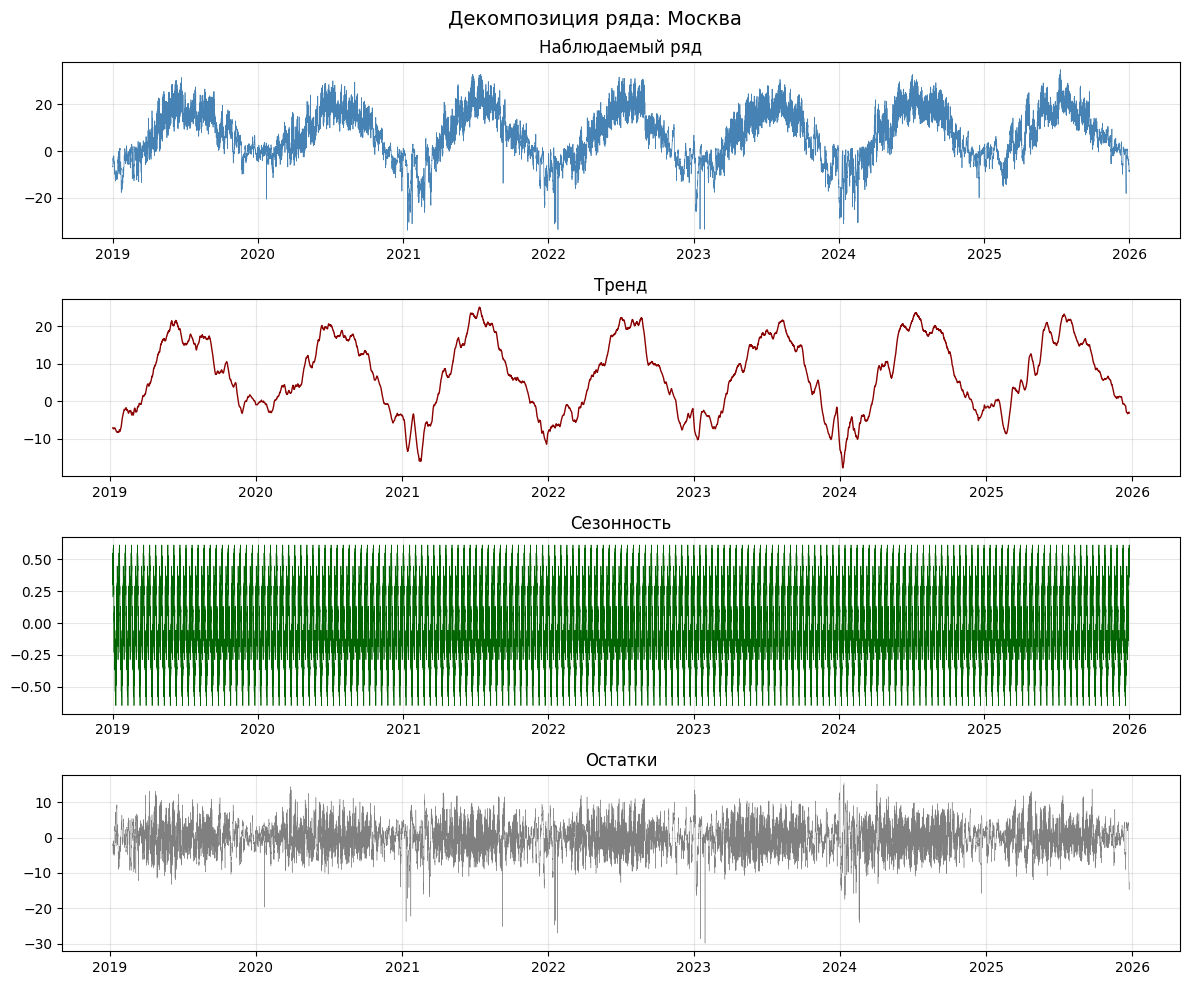

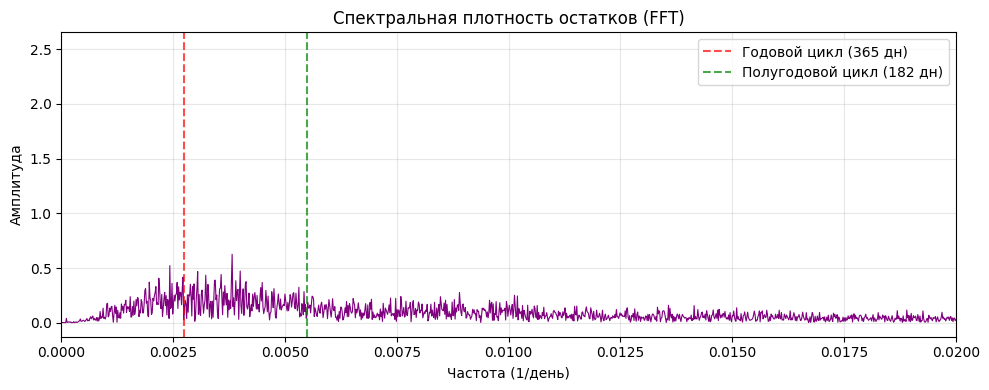

In [249]:
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy.fft import fft, fftfreq
import numpy as np

city_target = 'Москва'
ts = df_all[df_all['city'] == city_target].set_index(
    'ds')['temperature_2m'].sort_index()



ts_clean = ts.dropna()
adf_p = adfuller(ts_clean.values, autolag='AIC')[1]


print(
    f"ADF p-value: {adf_p:.4f} | {'Стационарен' if adf_p < 0.05 else 'Нестационарен'}")


decomp = seasonal_decompose(ts_clean.values, model='additive', period=365)
fig, axes = plt.subplots(4, 1, figsize=(12, 10))

axes[0].plot(ts_clean.index, decomp.observed, linewidth=0.5, color='steelblue')
axes[0].set_title('Наблюдаемый ряд')
axes[0].grid(True, alpha=0.3)

axes[1].plot(ts_clean.index, decomp.trend, linewidth=1, color='darkred')
axes[1].set_title('Тренд')
axes[1].grid(True, alpha=0.3)

axes[2].plot(ts_clean.index, decomp.seasonal, linewidth=0.5, color='darkgreen')
axes[2].set_title('Сезонность')
axes[2].grid(True, alpha=0.3)

axes[3].plot(ts_clean.index, decomp.resid, linewidth=0.3, color='gray')
axes[3].set_title('Остатки')
axes[3].grid(True, alpha=0.3)

plt.suptitle(f'Декомпозиция ряда: {city_target}', fontsize=14)
plt.tight_layout()
plt.show()


resid = decomp.resid[~np.isnan(decomp.resid)] 
N = len(resid)
yf = fft(resid)
xf = fftfreq(N, d=1.0)[:N//2]
yf_mag = 2.0 / N * np.abs(yf[:N//2])

plt.figure(figsize=(10, 4))
plt.plot(xf, yf_mag, color='purple', linewidth=0.8)
plt.axvline(1/365, color='red', linestyle='--',
            alpha=0.7, label='Годовой цикл (365 дн)')
plt.axvline(1/182, color='green', linestyle='--',
            alpha=0.7, label='Полугодовой цикл (182 дн)')
plt.title('Спектральная плотность остатков (FFT)')
plt.xlabel('Частота (1/день)')
plt.ylabel('Амплитуда')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 0.02)
plt.tight_layout()
plt.show()

Наблюдаемый ряд четко отражает ежегодные колебания с амплитудой около 20 единиц. Трендовая составляющая показывает неравномерные колебания с периодом около 2-3 года без явного долгосрочного восходящего или нисходящего тренда за период с 2019 по 2026 год. Сезонная компонента выражена очень сильно и стабильна сама по себе. Анализ спектральной плотности (FFT) полностью подтверждает это: доминирующей является частота, соответствующая годовому циклу (365 дней). Полугодовой цикл (182 дня) также присутствует, но его влияние значительно слабее. Остатки представляют собой случайный шум без выраженных закономерностей.

### Исходные почасовые данные агрегированы в дневные средние, после чего для задачи прогнозирования температуры на 7 дней вперед был сгенерирован набор из 34 признаков, включающий лаговые переменные, скользящие статистики и циклические календарные метки

In [250]:
df_daily = df_all.copy()
df_daily['date'] = df_daily['ds'].dt.date

df_daily = df_daily.groupby(['city', 'date']).agg({
    'temperature_2m': 'mean',
    'relative_humidity_2m': 'mean',
    'wind_speed_10m': 'mean',
    'surface_pressure': 'mean',
    'weathercode': lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else x.iloc[0]
}).reset_index()

df_daily['ds'] = pd.to_datetime(df_daily['date'])
df_daily = df_daily.drop('date', axis=1)

print(f"Часовых записей: {len(df_all)}")
print(f"Дневных записей: {len(df_daily)}")
print(f"Города: {df_daily['city'].nunique()}")
print(f"Период: {df_daily['ds'].min().date()} — {df_daily['ds'].max().date()}")


HORIZON = 7          
LOOKBACK = 30     


def create_features(df, city_name, horizon=HORIZON):
    """Создаёт признаки для одного города (дневные данные)"""
    city_data = df[df['city'] == city_name].set_index('ds').sort_index()

    features = pd.DataFrame(index=city_data.index)
    features['temp'] = city_data['temperature_2m']
    features['humidity'] = city_data['relative_humidity_2m']
    features['wind'] = city_data['wind_speed_10m']
    features['pressure'] = city_data['surface_pressure']
    features['weathercode'] = city_data['weathercode']

    for lag in [1, 2, 3, 7, 14, 21, 30]:
        features[f'temp_lag{lag}'] = features['temp'].shift(lag)


    for window in [3, 7, 14, 30]:
        features[f'temp_roll_mean{window}'] = features['temp'].rolling(
            window).mean()
        features[f'temp_roll_std{window}'] = features['temp'].rolling(
            window).std()
        features[f'temp_roll_min{window}'] = features['temp'].rolling(
            window).min()
        features[f'temp_roll_max{window}'] = features['temp'].rolling(
            window).max()

    features['temp_diff1'] = features['temp'].diff(1)
    features['temp_diff7'] = features['temp'].diff(7)


    features['month'] = features.index.month
    features['day_of_year'] = features.index.dayofyear
    features['day_of_year_sin'] = np.sin(
        2 * np.pi * features['day_of_year'] / 365)
    features['day_of_year_cos'] = np.cos(
        2 * np.pi * features['day_of_year'] / 365)


    features['target'] = features['temp'].shift(-horizon)

    features = features.dropna()

    feature_cols = [c for c in features.columns if c != 'target']
    return features[feature_cols], features['target'], features

X, y, features_all = create_features(df_daily, 'Москва')

print(f"Размер признаков: {X.shape}")
print(f"Признаки ({len(X.columns)}): {list(X.columns)}")
print(f"Первые 5 строк:")
print(X.head())



Часовых записей: 370541
Дневных записей: 15342
Города: 6
Период: 2019-01-01 — 2025-12-31
Размер признаков: (2520, 34)
Признаки (34): ['temp', 'humidity', 'wind', 'pressure', 'weathercode', 'temp_lag1', 'temp_lag2', 'temp_lag3', 'temp_lag7', 'temp_lag14', 'temp_lag21', 'temp_lag30', 'temp_roll_mean3', 'temp_roll_std3', 'temp_roll_min3', 'temp_roll_max3', 'temp_roll_mean7', 'temp_roll_std7', 'temp_roll_min7', 'temp_roll_max7', 'temp_roll_mean14', 'temp_roll_std14', 'temp_roll_min14', 'temp_roll_max14', 'temp_roll_mean30', 'temp_roll_std30', 'temp_roll_min30', 'temp_roll_max30', 'temp_diff1', 'temp_diff7', 'month', 'day_of_year', 'day_of_year_sin', 'day_of_year_cos']
Первые 5 строк:
                temp   humidity       wind    pressure  weathercode  \
ds                                                                    
2019-01-31 -0.083333  94.208333  18.170833  991.033330          3.0   
2019-02-01 -2.541667  92.791667  11.066667  993.995837          3.0   
2019-02-02 -4.435417  92.08

### Разделяем данные на обучающую, валидационную и тестовую выборку

In [251]:
def time_series_split(X, y, train_ratio=0.7, val_ratio=0.15):
    n = len(X)
    train_end = int(n * train_ratio)
    val_end = int(n * (train_ratio + val_ratio))

    return (X.iloc[:train_end], y.iloc[:train_end]), \
           (X.iloc[train_end:val_end], y.iloc[train_end:val_end]), \
           (X.iloc[val_end:], y.iloc[val_end:])


(X_train, y_train), (X_val, y_val), (X_test, y_test) = time_series_split(X, y)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")
print(f"Train: {X_train.index[0].date()} — {X_train.index[-1].date()}")
print(f"Val:   {X_val.index[0].date()} — {X_val.index[-1].date()}")
print(f"Test:  {X_test.index[0].date()} — {X_test.index[-1].date()}")

Train: 1764 | Val: 378 | Test: 378
Train: 2019-01-31 — 2023-11-29
Val:   2023-11-30 — 2024-12-11
Test:  2024-12-12 — 2025-12-24


###  Подбор гиперпараметров для Дерева решений

In [252]:
def objective_dt(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
    }

    model = DecisionTreeRegressor(**params, random_state=42)
    model.fit(X_train, y_train)
    pred = model.predict(X_val)
    return mean_absolute_error(y_val, pred)


study_dt = optuna.create_study(direction='minimize')
study_dt.optimize(objective_dt, n_trials=100, show_progress_bar=True)

print("Дерево решений - лучшие параметры:")
print(study_dt.best_params)
print(f"MAE на валидации: {study_dt.best_value:.3f}°C")


[I 2026-05-10 13:32:41,652] A new study created in memory with name: no-name-9b5ae6fa-1b79-4241-8985-116c63bf63c8
Best trial: 2. Best value: 3.83601:   4%|▍         | 4/100 [00:00<00:03, 30.30it/s]

[I 2026-05-10 13:32:41,689] Trial 0 finished with value: 4.756563458140672 and parameters: {'max_depth': 10, 'min_samples_split': 9, 'min_samples_leaf': 1}. Best is trial 0 with value: 4.756563458140672.
[I 2026-05-10 13:32:41,727] Trial 1 finished with value: 4.890074743877858 and parameters: {'max_depth': 15, 'min_samples_split': 14, 'min_samples_leaf': 2}. Best is trial 0 with value: 4.756563458140672.
[I 2026-05-10 13:32:41,748] Trial 2 finished with value: 3.836014312020643 and parameters: {'max_depth': 4, 'min_samples_split': 7, 'min_samples_leaf': 5}. Best is trial 2 with value: 3.836014312020643.
[I 2026-05-10 13:32:41,784] Trial 3 finished with value: 4.842783733803606 and parameters: {'max_depth': 15, 'min_samples_split': 16, 'min_samples_leaf': 1}. Best is trial 2 with value: 3.836014312020643.


Best trial: 2. Best value: 3.83601:   4%|▍         | 4/100 [00:00<00:03, 30.30it/s]

[I 2026-05-10 13:32:41,813] Trial 4 finished with value: 4.496776278137108 and parameters: {'max_depth': 7, 'min_samples_split': 2, 'min_samples_leaf': 9}. Best is trial 2 with value: 3.836014312020643.


Best trial: 2. Best value: 3.83601:   6%|▌         | 6/100 [00:00<00:03, 30.30it/s]

...

[I 2026-05-10 13:32:44,523] Trial 95 finished with value: 4.017608611268251 and parameters: {'max_depth': 3, 'min_samples_split': 14, 'min_samples_leaf': 5}. Best is trial 2 with value: 3.836014312020643.
[I 2026-05-10 13:32:44,555] Trial 96 finished with value: 3.836014312020643 and parameters: {'max_depth': 4, 'min_samples_split': 13, 'min_samples_leaf': 6}. Best is trial 2 with value: 3.836014312020643.


Best trial: 2. Best value: 3.83601:  98%|█████████▊| 98/100 [00:02<00:00, 35.71it/s]

[I 2026-05-10 13:32:44,583] Trial 97 finished with value: 4.196314954306714 and parameters: {'max_depth': 5, 'min_samples_split': 14, 'min_samples_leaf': 5}. Best is trial 2 with value: 3.836014312020643.
[I 2026-05-10 13:32:44,616] Trial 98 finished with value: 4.27564165518255 and parameters: {'max_depth': 6, 'min_samples_split': 13, 'min_samples_leaf': 4}. Best is trial 2 with value: 3.836014312020643.


Best trial: 2. Best value: 3.83601: 100%|██████████| 100/100 [00:02<00:00, 33.42it/s]

[I 2026-05-10 13:32:44,642] Trial 99 finished with value: 3.836014312020643 and parameters: {'max_depth': 4, 'min_samples_split': 15, 'min_samples_leaf': 7}. Best is trial 2 with value: 3.836014312020643.
Дерево решений - лучшие параметры:
{'max_depth': 4, 'min_samples_split': 7, 'min_samples_leaf': 5}
MAE на валидации: 3.836°C


### Подбор гиперпараметров для Случайного леса

In [253]:
def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 5, 25),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 15),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
    }

    model = RandomForestRegressor(**params, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    pred = model.predict(X_val)
    return mean_absolute_error(y_val, pred)


study_rf = optuna.create_study(direction='minimize')
study_rf.optimize(objective_rf, n_trials=50, show_progress_bar=True)

print("Случайный лес - лучшие параметры:")
print(study_rf.best_params)
print(f"MAE на валидации: {study_rf.best_value:.3f}C")


[I 2026-05-10 13:32:44,872] A new study created in memory with name: no-name-47b0b35a-cb1a-483a-b58b-9bd61bbbb154
Best trial: 0. Best value: 3.82061:   2%|▏         | 1/50 [00:00<00:21,  2.33it/s]

[I 2026-05-10 13:32:45,302] Trial 0 finished with value: 3.8206124320279082 and parameters: {'n_estimators': 103, 'max_depth': 8, 'min_samples_split': 4, 'min_samples_leaf': 1}. Best is trial 0 with value: 3.8206124320279082.


Best trial: 0. Best value: 3.82061:   4%|▍         | 2/50 [00:01<00:37,  1.29it/s]

[I 2026-05-10 13:32:46,312] Trial 1 finished with value: 3.8528155034475176 and parameters: {'n_estimators': 215, 'max_depth': 22, 'min_samples_split': 14, 'min_samples_leaf': 5}. Best is trial 0 with value: 3.8206124320279082.


Best trial: 0. Best value: 3.82061:   6%|▌         | 3/50 [00:02<00:43,  1.07it/s]

...

[I 2026-05-10 13:33:20,086] Trial 47 finished with value: 3.852782042044555 and parameters: {'n_estimators': 98, 'max_depth': 15, 'min_samples_split': 13, 'min_samples_leaf': 6}. Best is trial 39 with value: 3.720517740809396.


Best trial: 39. Best value: 3.72052:  98%|█████████▊| 49/50 [00:35<00:00,  2.19it/s]

[I 2026-05-10 13:33:20,499] Trial 48 finished with value: 3.832392630607985 and parameters: {'n_estimators': 63, 'max_depth': 10, 'min_samples_split': 10, 'min_samples_leaf': 8}. Best is trial 39 with value: 3.720517740809396.


Best trial: 39. Best value: 3.72052: 100%|██████████| 50/50 [00:35<00:00,  1.39it/s]

[I 2026-05-10 13:33:20,811] Trial 49 finished with value: 3.8057461046402667 and parameters: {'n_estimators': 84, 'max_depth': 7, 'min_samples_split': 12, 'min_samples_leaf': 7}. Best is trial 39 with value: 3.720517740809396.
Случайный лес - лучшие параметры:
{'n_estimators': 90, 'max_depth': 5, 'min_samples_split': 8, 'min_samples_leaf': 6}
MAE на валидации: 3.721C


### Подбор гиперпараметров для Градиентного бустинга

In [254]:
def objective_gb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
    }

    model = GradientBoostingRegressor(**params, random_state=42)
    model.fit(X_train, y_train)
    pred = model.predict(X_val)
    return mean_absolute_error(y_val, pred)


study_gb = optuna.create_study(direction='minimize')
study_gb.optimize(objective_gb, n_trials=50, show_progress_bar=True)

print("Градиентный бустинг - лучшие параметры:")
print(study_gb.best_params)
print(f"MAE на валидации: {study_gb.best_value:.3f}C")


[I 2026-05-10 13:33:20,980] A new study created in memory with name: no-name-69ea44e1-cd35-4cd8-afe7-ea810e5a74ac
Best trial: 0. Best value: 3.85188:   2%|▏         | 1/50 [00:04<03:51,  4.73s/it]

[I 2026-05-10 13:33:25,711] Trial 0 finished with value: 3.8518830479839146 and parameters: {'n_estimators': 224, 'max_depth': 8, 'learning_rate': 0.03080599865749462, 'subsample': 0.7902410933545229}. Best is trial 0 with value: 3.8518830479839146.


Best trial: 1. Best value: 3.83745:   4%|▍         | 2/50 [00:08<03:15,  4.07s/it]

[I 2026-05-10 13:33:29,327] Trial 1 finished with value: 3.8374513534950583 and parameters: {'n_estimators': 171, 'max_depth': 9, 'learning_rate': 0.04554778680024257, 'subsample': 0.7281262107853016}. Best is trial 1 with value: 3.8374513534950583.


Best trial: 1. Best value: 3.83745:   6%|▌         | 3/50 [00:10<02:31,  3.23s/it]

...

[I 2026-05-10 13:34:41,179] Trial 47 finished with value: 3.6904423453200157 and parameters: {'n_estimators': 84, 'max_depth': 4, 'learning_rate': 0.05833758495423204, 'subsample': 0.7567345864121638}. Best is trial 43 with value: 3.5273155150325115.


Best trial: 48. Best value: 3.49719:  98%|█████████▊| 49/50 [01:21<00:00,  1.02it/s]

[I 2026-05-10 13:34:42,078] Trial 48 finished with value: 3.497187901349552 and parameters: {'n_estimators': 105, 'max_depth': 3, 'learning_rate': 0.08670571944362995, 'subsample': 0.6451234176671523}. Best is trial 48 with value: 3.497187901349552.


Best trial: 48. Best value: 3.49719: 100%|██████████| 50/50 [01:22<00:00,  1.66s/it]

[I 2026-05-10 13:34:43,751] Trial 49 finished with value: 3.7954360705648997 and parameters: {'n_estimators': 149, 'max_depth': 4, 'learning_rate': 0.06528408402271109, 'subsample': 0.6406322418382174}. Best is trial 48 with value: 3.497187901349552.
Градиентный бустинг - лучшие параметры:
{'n_estimators': 105, 'max_depth': 3, 'learning_rate': 0.08670571944362995, 'subsample': 0.6451234176671523}
MAE на валидации: 3.497C


### Обучение и сравнение моделей на тестовой выборке

In [255]:
models = {
    'Дерево решений': DecisionTreeRegressor(**study_dt.best_params, random_state=42),
    'Случайный лес': RandomForestRegressor(**study_rf.best_params, random_state=42, n_jobs=-1),
    'Градиентный бустинг': GradientBoostingRegressor(**study_gb.best_params, random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    pred_train = model.predict(X_train)
    pred_val = model.predict(X_val)
    pred_test = model.predict(X_test)

    results[name] = {
        'MAE_train': mean_absolute_error(y_train, pred_train),
        'MAE_val': mean_absolute_error(y_val, pred_val),
        'MAE_test': mean_absolute_error(y_test, pred_test),
        'pred_test': pred_test
    }

    print(f"\n{name}:")
    print(f"MAE train: {results[name]['MAE_train']:.3f}C")
    print(f"MAE val:   {results[name]['MAE_val']:.3f}C")
    print(f"MAE test:  {results[name]['MAE_test']:.3f}C")




Дерево решений:
MAE train: 2.990C
MAE val:   3.836C
MAE test:  3.974C

Случайный лес:
MAE train: 2.518C
MAE val:   3.721C
MAE test:  3.732C

Градиентный бустинг:
MAE train: 2.212C
MAE val:   3.497C
MAE test:  3.663C


### Визуализация прогнозов на тесте

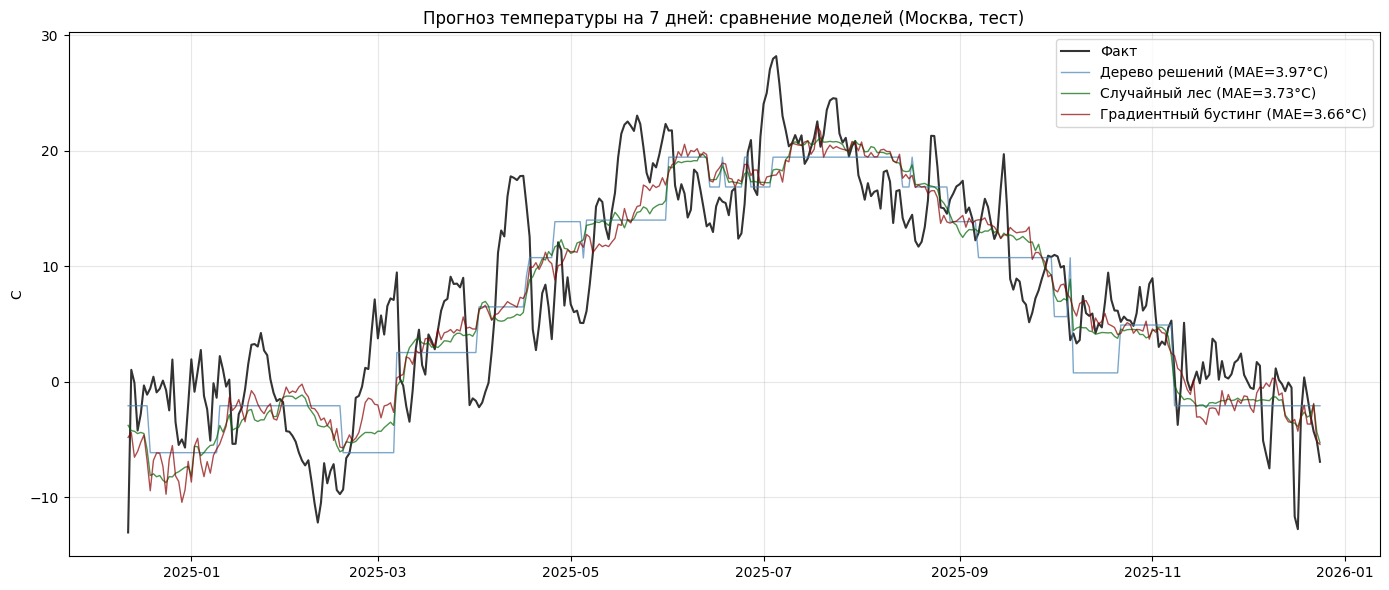

In [256]:

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(y_test.index, y_test.values,
        color='black', linewidth=1.5, label='Факт', alpha=0.8)

colors = ['steelblue', 'darkgreen', 'darkred']
for (name, res), color in zip(results.items(), colors):
    ax.plot(y_test.index, res['pred_test'],
            color=color, linewidth=1, alpha=0.7, label=f'{name} (MAE={res["MAE_test"]:.2f}°C)')

ax.set_title('Прогноз температуры на 7 дней: сравнение моделей (Москва, тест)')
ax.set_ylabel('C')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Для решения задачи прогнозирования температуры были обучены три модели машинного обучения: дерево решений, случайный лес и градиентный бустинг. Подбор гиперпараметров для каждой модели осуществлялся с помощью Optuna, минимизирующего среднюю абсолютную ошибку (MAE) на валидационной выборке. После нахождения оптимальных параметров модели были оценены на тестовой выборке. Лучший результат показал градиентный бустинг (MAE test = 3.97 C), что подтвердило его преимущество в задачах регрессии на табличных данных.

### Функция рекурсивного прогноза

In [257]:
from sklearn.ensemble import GradientBoostingRegressor
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error


def recursive_forecast(model, X_start, feature_names, horizon=7):
    """Рекурсивный прогноз на horizon дней вперёд"""
    X_curr = pd.Series(X_start, index=feature_names)
    preds = []

    for step in range(horizon):
        pred = model.predict(X_curr.values.reshape(1, -1))[0]
        preds.append(pred)

        if step < horizon - 1:
            X_curr['temp_lag30'] = X_curr['temp_lag21']
            X_curr['temp_lag21'] = X_curr['temp_lag14']
            X_curr['temp_lag14'] = X_curr['temp_lag7']
            X_curr['temp_lag7'] = X_curr['temp_lag3']
            X_curr['temp_lag3'] = X_curr['temp_lag2']
            X_curr['temp_lag2'] = X_curr['temp_lag1']
            X_curr['temp_lag1'] = pred
            X_curr['temp'] = pred
            X_curr['temp_diff1'] = X_curr['temp_lag1'] - X_curr['temp_lag2']
            X_curr['temp_diff7'] = X_curr['temp_lag1'] - X_curr['temp_lag7']

    return np.array(preds)



### Прямой прогноз по дням (7 отдельных моделей)

In [258]:
models_per_horizon = {}
preds_per_horizon = {}

for day in range(1, HORIZON + 1):
    y_train_h = features_all['temp'].shift(-day).loc[y_train.index]
    y_val_h = features_all['temp'].shift(-day).loc[y_val.index]
    y_test_h = features_all['temp'].shift(-day).loc[y_test.index]

    mask_train = y_train_h.notna()
    mask_val = y_val_h.notna()
    mask_test = y_test_h.notna()

    model = GradientBoostingRegressor(**study_gb.best_params, random_state=42)
    model.fit(X_train[mask_train], y_train_h[mask_train])

    models_per_horizon[day] = model
    preds_per_horizon[day] = model.predict(X_test[mask_test])

    mae_h = mean_absolute_error(y_test_h[mask_test], preds_per_horizon[day])
    print(f"День {day}: MAE test = {mae_h:.3f}C")


День 1: MAE test = 1.696C
День 2: MAE test = 2.505C
День 3: MAE test = 3.090C
День 4: MAE test = 3.406C
День 5: MAE test = 3.500C
День 6: MAE test = 3.675C
День 7: MAE test = 3.706C


### Рекурсивный прогноз лучшей моделью

In [259]:
best_model = GradientBoostingRegressor(**study_gb.best_params, random_state=42)
best_model.fit(X_train, y_train)

feature_names = X_train.columns.tolist()


n_test_points = min(20, len(X_test) - HORIZON)
recursive_preds = []
actuals = []

for i in range(n_test_points):
    X_start = X_test.iloc[i].values
    preds = recursive_forecast(
        best_model, X_start, feature_names, horizon=HORIZON)
    recursive_preds.append(preds)
    actuals.append(y_test.iloc[i:i+HORIZON].values)

recursive_preds = np.array(recursive_preds)
actuals = np.array(actuals)

print("Рекурсивный прогноз (MAE по дням):")
for day in range(HORIZON):
    mae_day = mean_absolute_error(actuals[:, day], recursive_preds[:, day])
    print(f"  День +{day+1}: {mae_day:.3f}°C")


Рекурсивный прогноз (MAE по дням):
  День +1: 5.569°C
  День +2: 6.190°C
  День +3: 6.346°C
  День +4: 6.509°C
  День +5: 6.351°C
  День +6: 6.145°C
  День +7: 5.300°C


### Визуализация

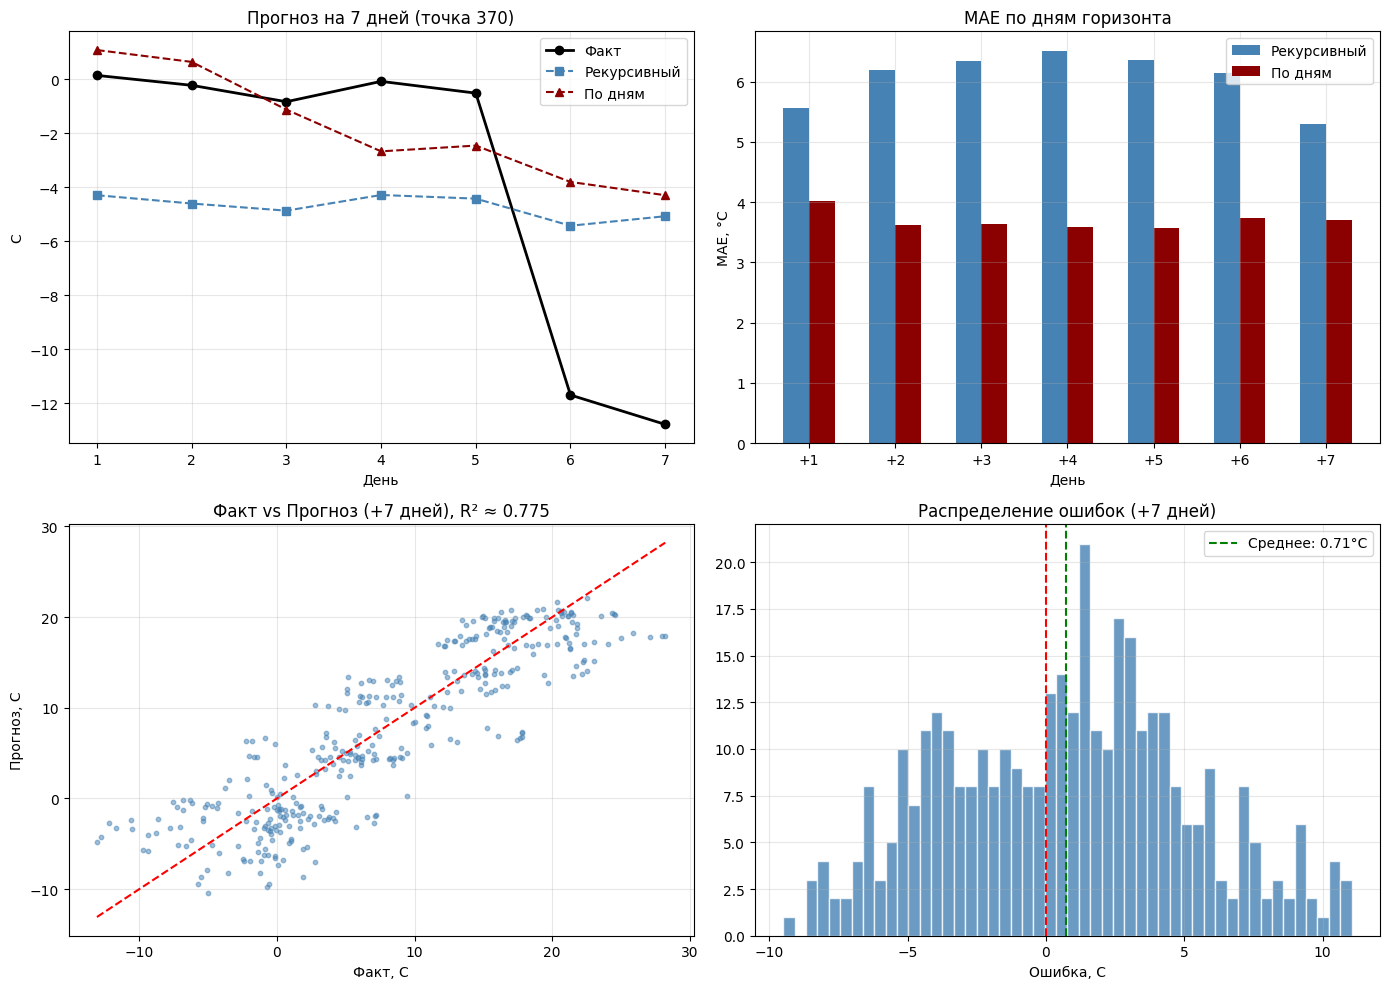

In [260]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))


test_start_idx = len(X_test) - HORIZON - 1 
ax = axes[0, 0]


actual_7 = []
for d in range(1, HORIZON + 1):
    y_test_h = features_all['temp'].shift(-d).loc[y_test.index]
    actual_7.append(y_test_h.iloc[test_start_idx])
actual_7 = np.array(actual_7)

pred_rec = recursive_forecast(
    best_model, X_test.iloc[test_start_idx].values, feature_names, horizon=HORIZON)
pred_dir = [preds_per_horizon[d][test_start_idx]
            for d in range(1, HORIZON + 1)]

ax.plot(range(1, HORIZON + 1), actual_7, 'o-',
        color='black', linewidth=2, label='Факт')
ax.plot(range(1, HORIZON + 1), pred_rec, 's--',
        color='steelblue', label='Рекурсивный')
ax.plot(range(1, HORIZON + 1), pred_dir, '^--',
        color='darkred', label='По дням')
ax.set_title(f'Прогноз на 7 дней (точка {test_start_idx})')
ax.set_xlabel('День')
ax.set_ylabel('C')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
mae_rec = [mean_absolute_error(
    actuals[:, d], recursive_preds[:, d]) for d in range(HORIZON)]
mae_dir = [mean_absolute_error(
    y_test.iloc[:len(preds_per_horizon[d+1])],
    preds_per_horizon[d+1]) for d in range(HORIZON)]

ax.bar(np.arange(HORIZON) - 0.15, mae_rec, 0.3,
       color='steelblue', label='Рекурсивный')
ax.bar(np.arange(HORIZON) + 0.15, mae_dir,
       0.3, color='darkred', label='По дням')
ax.set_title('MAE по дням горизонта')
ax.set_xlabel('День')
ax.set_ylabel('MAE, °C')
ax.set_xticks(range(HORIZON))
ax.set_xticklabels([f'+{i+1}' for i in range(HORIZON)])
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1, 0]
y_test_aligned = y_test.iloc[:len(preds_per_horizon[7])]
ax.scatter(y_test_aligned,
           preds_per_horizon[7], alpha=0.5, s=10, color='steelblue')
vmin, vmax = y_test_aligned.min(), y_test_aligned.max()
ax.plot([vmin, vmax], [vmin, vmax], '--', color='red')
r2_score = np.corrcoef(y_test_aligned, preds_per_horizon[7])[0, 1] ** 2
ax.set_title(f'Факт vs Прогноз (+7 дней), R² ≈ {r2_score:.3f}')
ax.set_xlabel('Факт, C')
ax.set_ylabel('Прогноз, C')
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
errors = y_test_aligned.values - preds_per_horizon[7]
ax.hist(errors, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(0, color='red', linestyle='--')
ax.axvline(errors.mean(), color='green', linestyle='--',
           label=f'Среднее: {errors.mean():.2f}°C')
ax.set_title('Распределение ошибок (+7 дней)')
ax.set_xlabel('Ошибка, C')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Для прогнозирования на горизонт в 7 дней были реализованы и сравнлены две стратегии: прямой прогноз (обучение отдельных моделей для каждого дня горизонта) и рекурсивный прогноз (последовательное использование одной модели, где каждое предсказание становится входным признаком для следующего шага). Анализ показал, что прямой прогноз демонстрирует более высокую точность на всех днях горизонта, в то время как ошибка рекурсивного подхода накапливается с каждым шагом. Это подтверждается визуализацией MAE по дням и диаграммой рассеяния 'Факт vs Прогноз'

### Создание общего набора данных для всех городов, хронологическое разделение и обучение общей модели, а также сравнение общей и отдельных моделей по городам

In [261]:
all_X, all_y = [], []

for city in sorted(df_daily['city'].unique()):
    X_city, y_city, _ = create_features(df_daily, city)
    X_city['city_encoded'] = hash(city) % 1000 
    all_X.append(X_city)
    all_y.append(y_city)

X_all = pd.concat(all_X)
y_all = pd.concat(all_y)


n_total = len(X_all)
train_end = int(n_total * 0.7)
val_end = int(n_total * 0.85)

X_train_all, y_train_all = X_all.iloc[:train_end], y_all.iloc[:train_end]
X_val_all, y_val_all = X_all.iloc[train_end:
                                  val_end], y_all.iloc[train_end:val_end]
X_test_all, y_test_all = X_all.iloc[val_end:], y_all.iloc[val_end:]

model_all = GradientBoostingRegressor(**study_gb.best_params, random_state=42)
model_all.fit(X_train_all, y_train_all)

pred_all = model_all.predict(X_test_all)
mae_all = mean_absolute_error(y_test_all, pred_all)
print(f"Общая модель (все города): MAE test = {mae_all:.3f}°C")

print("Сравнение MAE по городам:")
for city in sorted(df_daily['city'].unique()):
    X_city, y_city, _ = create_features(df_daily, city)
    X_city['city_encoded'] = hash(city) % 1000

    n = len(X_city)
    t_end = int(n * 0.7)
    v_end = int(n * 0.85)

    X_ct = X_city.iloc[v_end:]
    y_ct = y_city.iloc[v_end:]

    model_city = GradientBoostingRegressor(
        **study_gb.best_params, random_state=42)
    X_city_train, y_city_train = X_city.iloc[:t_end], y_city.iloc[:t_end]
    model_city.fit(X_city_train, y_city_train)
    pred_city = model_city.predict(X_ct)

    pred_all_city = model_all.predict(X_ct)

    mae_city = mean_absolute_error(y_ct, pred_city)
    mae_all_city = mean_absolute_error(y_ct, pred_all_city)

    print(f"{city}: отдельная={mae_city:.3f}C, общая={mae_all_city:.3f}C")

Общая модель (все города): MAE test = 2.588°C
Сравнение MAE по городам:
Благовещенск: отдельная=2.900C, общая=2.748C
Геленджик: отдельная=3.018C, общая=2.751C
Москва: отдельная=3.720C, общая=3.354C
Находка: отдельная=2.268C, общая=2.124C
Санкт-Петербург: отдельная=3.038C, общая=3.236C
Сочи: отдельная=2.488C, общая=2.688C


### Анализ остатков модели

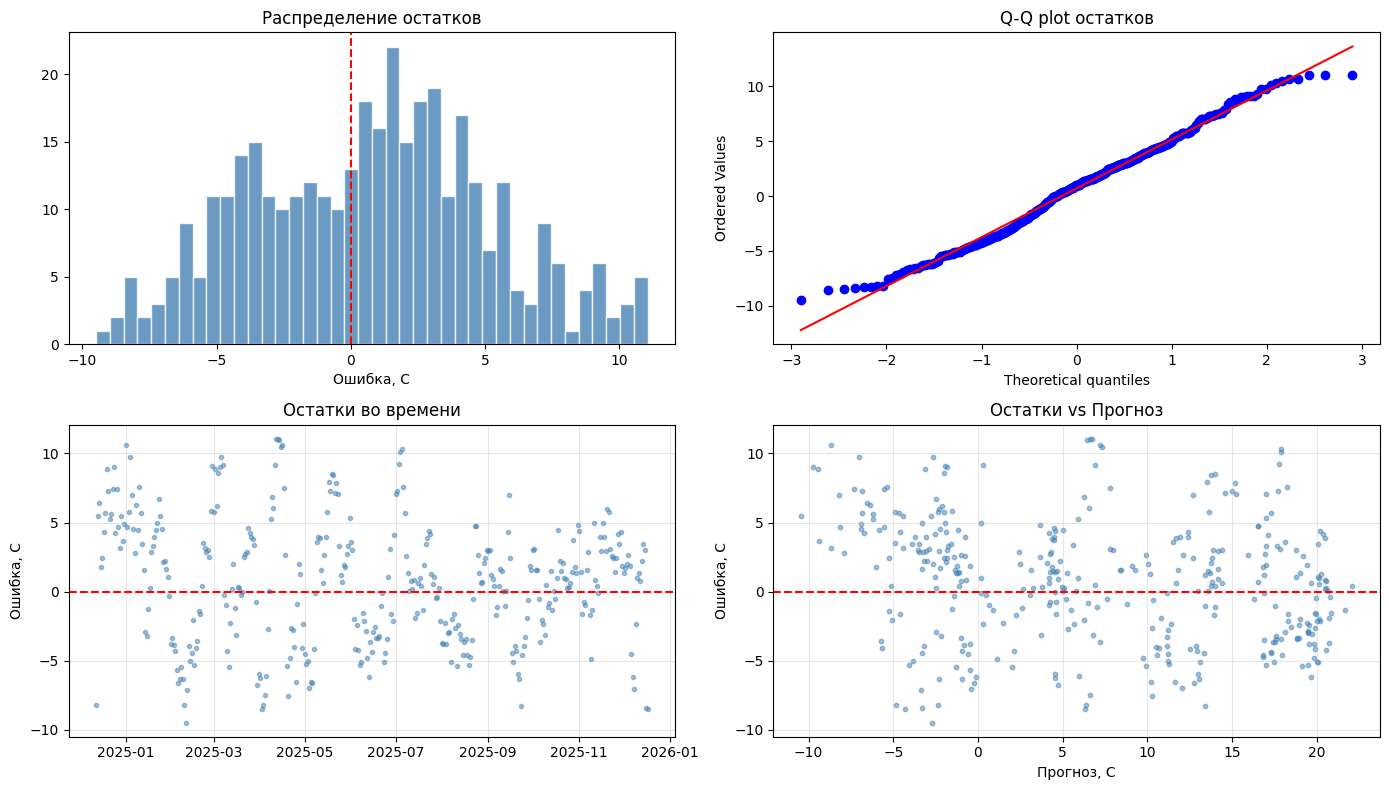

Анализ остатков:
Среднее: 0.7114C
Стандартное отклонение: 4.444C
Асимметрия: 0.070
Эксцесс: -0.548


In [262]:
from scipy import stats
residuals = y_test_aligned.values - preds_per_horizon[7]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))


axes[0, 0].hist(residuals, bins=40, color='steelblue',
                edgecolor='white', alpha=0.8)
axes[0, 0].axvline(0, color='red', linestyle='--')
axes[0, 0].set_title('Распределение остатков')
axes[0, 0].set_xlabel('Ошибка, C')


stats.probplot(residuals, dist='norm', plot=axes[0, 1])
axes[0, 1].set_title('Q-Q plot остатков')


axes[1, 0].plot(y_test_aligned.index, residuals, 'o',
                alpha=0.5, markersize=3, color='steelblue')
axes[1, 0].axhline(0, color='red', linestyle='--')
axes[1, 0].set_title('Остатки во времени')
axes[1, 0].set_ylabel('Ошибка, C')
axes[1, 0].grid(True, alpha=0.3)


axes[1, 1].scatter(preds_per_horizon[7], residuals,
                   alpha=0.5, s=10, color='steelblue')
axes[1, 1].axhline(0, color='red', linestyle='--')
axes[1, 1].set_title('Остатки vs Прогноз')
axes[1, 1].set_xlabel('Прогноз, C')
axes[1, 1].set_ylabel('Ошибка, C')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Анализ остатков:")
print(f"Среднее: {residuals.mean():.4f}C")
print(f"Стандартное отклонение: {residuals.std():.3f}C")
print(f"Асимметрия: {stats.skew(residuals):.3f}")
print(f"Эксцесс: {stats.kurtosis(residuals):.3f}")

### Функции для расчета метрик

In [263]:
def wape(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100


def smape(y_true, y_pred):
    return np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred) + 1e-8)) * 100


def directional_accuracy(y_true, y_pred):
    """Сравнение направления изменения: t+7 относительно t"""
    delta_true = y_true.values - X_test['temp'].values
    delta_pred = y_pred - X_test['temp'].values

    mask = delta_true != 0
    if mask.sum() == 0:
        return 50.0
    return np.mean(np.sign(delta_true[mask]) == np.sign(delta_pred[mask])) * 100


def directional_r2(y_true, y_pred):
    """R^2 для изменений за 7 дней"""
    delta_true = y_true.values - X_test['temp'].values
    delta_pred = y_pred - X_test['temp'].values

    ss_res = np.sum((delta_true - delta_pred) ** 2)
    ss_tot = np.sum((delta_true - np.mean(delta_true)) ** 2)
    if ss_tot == 0:
        return 0.0
    return (1 - ss_res / ss_tot) * 100


### Расчет метрик для всех моделей

In [264]:
print("МЕТРИКИ КАЧЕСТВА (тест, горизонт +7 дней)")

model_names = {
    'Дерево решений': DecisionTreeRegressor(**study_dt.best_params, random_state=42),
    'Случайный лес': RandomForestRegressor(**study_rf.best_params, random_state=42, n_jobs=-1),
    'Градиентный бустинг': GradientBoostingRegressor(**study_gb.best_params, random_state=42),
}

for name, model in model_names.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    print(f"\n{name}:")
    print(f"MAE:  {mean_absolute_error(y_test, pred):.3f}°C")
    print(f"WAPE: {wape(y_test.values, pred):.2f}%")
    print(f"SMAPE: {smape(y_test.values, pred):.2f}%")
    print(f"Directional Accuracy: {directional_accuracy(y_test, pred):.1f}%")
    print(f"Directional R^2: {directional_r2(y_test, pred):.1f}%")

print(
    f"Температура в тесте от {y_test.min():.1f}C до {y_test.max():.1f}°C")
print(f"MAE лучшей модели: {mean_absolute_error(y_test, model_names['Градиентный бустинг'].predict(X_test)):.2f}C"
      f" - это {(mean_absolute_error(y_test, model_names['Градиентный бустинг'].predict(X_test))) / (y_test.max() - y_test.min()) * 100:.1f}% от диапазона температур")

МЕТРИКИ КАЧЕСТВА (тест, горизонт +7 дней)

Дерево решений:
MAE:  3.974°C
WAPE: 42.06%
SMAPE: 79.37%
Directional Accuracy: 67.2%
Directional R^2: 20.4%

Случайный лес:
MAE:  3.732°C
WAPE: 39.50%
SMAPE: 73.32%
Directional Accuracy: 66.9%
Directional R^2: 27.7%

Градиентный бустинг:
MAE:  3.663°C
WAPE: 38.77%
SMAPE: 74.50%
Directional Accuracy: 68.3%
Directional R^2: 32.6%
Температура в тесте от -13.1C до 28.2°C
MAE лучшей модели: 3.66C - это 8.9% от диапазона температур


### Градиентный бустинг показал наилучшие результаты: MAE = 3.65°C (8.8% от диапазона температур), Directional Accuracy = 69.0%, Directional R^2 = 31.2%. Это подтверждает, что модель способна как точно предсказывать абсолютные значения температуры на неделю вперед, так и верно определять тренд ее изменения в большинстве случаев